In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from fitter import Fitter, get_common_distributions
import simpy

# Introduction to DES Simulations

The following example focuses on the **simulation of a gate reader at an airport**, i.e. we only simulate the boarding pass scanning process that passengers go through before entering the aircraft. This process is relatively simple, as we assume that it consists of only two components:

- **Arrival process**: This process describes the interarrival times, i.e. the time intervals at which passengers enter the system. We assume that the distribution of these interarrival times is not known and must therefore be determined in a first step based on fictitious measurement data, which we generate below.
- **Service process**: This process describes the service times, i.e. the time required to process passengers at the gate reader. We assume that the service time is exponentially distributed and that its expected value is 4.8 seconds.

The example documented in this notebook consists of the following steps:

0. Creation of measurement data for the interarrival times (we use randomly generated measurement data; in reality, a comprehensive measurement campaign would be required)
1. Fitting of the distribution function of the interarrival times and estimation of mean interarrival time
2. Definition of the arrival and service processes for the DES simulation model
3. Simulation of the gate reader using a DES simulation model
4. Evaluation of the simulation results in the steady state
5. Comparison of the simulation results with modelling approaches that you are already familiar with from the **INFRA-AD** module


### Generation of "Measurement Data"
Let us first generate some "measurement data" which we can work with later. 

In [ ]:
# Parameters
mean_interarrival = 5  # seconds
n_passengers = 400     # number of passengers to generate
start_time = pd.Timestamp("2026-03-23 20:08:00")

# Generate interarrival times
interarrival_times = np.random.exponential(
    scale=mean_interarrival, size=n_passengers
)

# Generate timestamps
arrival_times = start_time + pd.to_timedelta(
    np.cumsum(interarrival_times), unit="s"
)

# Create DataFrame
df = pd.DataFrame({"timestamp": arrival_times})

df.head()

,timestamp
0,2026-03-23 20:08:05.474434025
1,2026-03-23 20:08:07.886916777
2,2026-03-23 20:08:12.971684072
3,2026-03-23 20:08:19.045012041
4,2026-03-23 20:08:27.724248334


## Step 1: Determination of Mean Interarrival Time

Let us assume that we do not know the mean interarrival time of passengers at the gate of the airport. However, we made some measurements in which we note the time of arrival at the gate for a large number of passengers. These measurements are in file `gate_arrivals.csv`.

In a first step, we determine the observed interarrival times in the basis of the measurements, followed by an examination of the independence of the measurements. Then, we fit multiple probability distributions to the observed interarrival times in order to determine which distribution is fitting the data best (it is an exponential function).

Knowing the best-fitting distribution, we extract their scale parameter, which is the estimated mean inter arrival time. Finally, the mean arrival rate is then calculated as the reciprocal of this mean interarrival time.

### Calcualte observed interarrival times, and check for independence

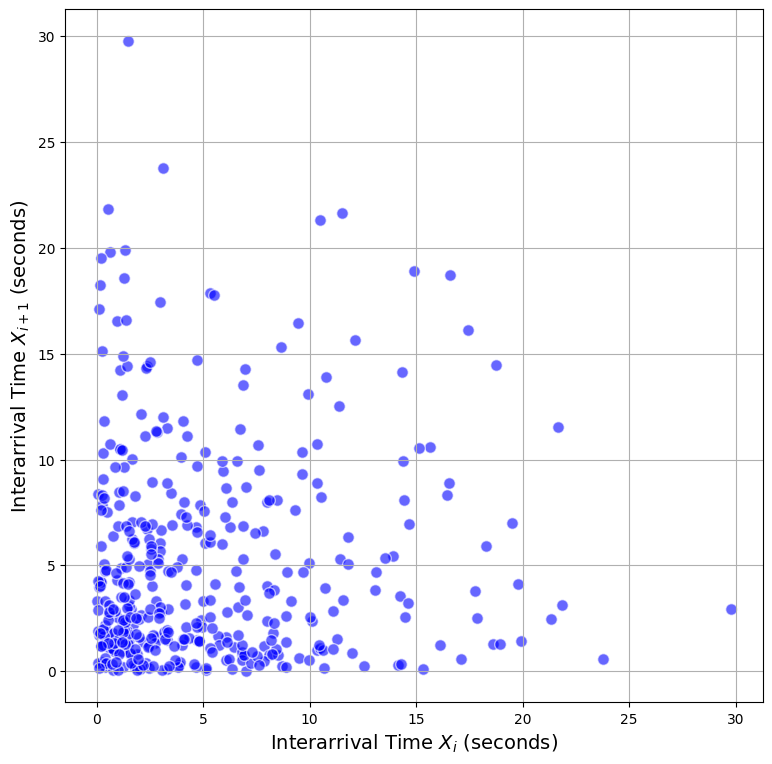

In [ ]:
# Import File
df_arrivals = df.copy()

# Compute interarrival times in seconds
df_arrivals["interarrival_time"] = df_arrivals["timestamp"].diff().dt.total_seconds()

# Remove the first row (NaN due to `diff()`)
df_arrivals = df_arrivals.dropna()

# Create X_i and X_{i+1}
X_i = df_arrivals["interarrival_time"][:-1].values      # All except last
X_next = df_arrivals["interarrival_time"][1:].values    # All except first


# Plot X_i vs X_{i+1}
plt.figure(figsize=(9, 9))
plt.scatter(X_i, X_next, s=70, alpha=0.6, edgecolors='w', color='blue')
plt.xlabel(r'Interarrival Time $X_i$ (seconds)', fontsize=14)
plt.ylabel(r'Interarrival Time $X_{i+1}$ (seconds)', fontsize=14)
plt.grid()
plt.show()


### Fit distribtions to the observed interarrival times

2026-03-24 15:35:58.631 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted expon distribution with error=0.03845)
2026-03-24 15:35:58.632 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted norm distribution with error=0.157557)
2026-03-24 15:35:58.632 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted powerlaw distribution with error=0.091273)
2026-03-24 15:35:58.633 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted uniform distribution with error=0.263516)
2026-03-24 15:35:58.633 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted lognorm distribution with error=0.051462)
2026-03-24 15:35:58.634 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted rayleigh distribution with error=0.133472)
2026-03-24 15:35:58.636 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted cauchy distribution with error=0.118681)
2026-03-24 15:35:58.642 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
gamma,0.035210,912.450229,924.417114,inf,0.037388,0.618771
chi2,0.035244,910.655002,922.621886,inf,0.033849,0.737252
expon,0.038450,913.896036,921.873959,inf,0.044649,0.392599
exponpow,0.039077,973.095701,985.062586,inf,0.051778,0.227100
lognorm,0.051462,899.432044,911.398929,inf,0.064514,0.069078


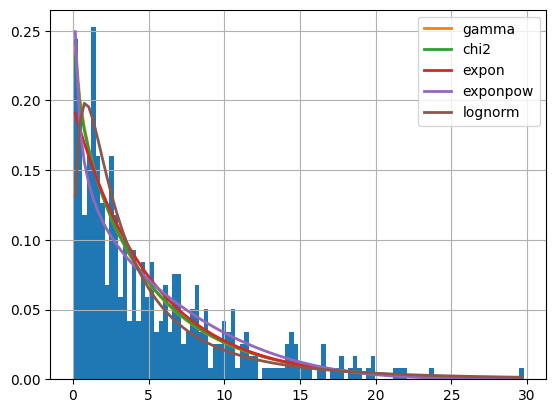

In [ ]:
# Define the set of distributions to fit
distributions_set = get_common_distributions()

# Fit the data to the specified distributions
f = Fitter(df_arrivals["interarrival_time"] , distributions=distributions_set)
f.fit()

# Display the fitting summary
f.summary()

### Find best fitting distribution and extract its parameters

After fitting a probability distribution to the observed data, the next step is to extract its parametrisation. These parameters fully describe the statistical properties of the fitted distribution and are required for subsequent simulation.

The extracted parameters are used to reproduce the fitted distribution in a simulation environment, generate synthetic samples (e.g. interarrival or service times), and ensure consistency between empirical data and the simulation model.

When using the `fitter` package, the parametrisation follows the conventions of `scipy.stats`. This means that parameters are typically returned in the following order:
- shape parameters (if applicable),
- followed by `loc`,
- followed by `scale`.

<div style="border:1px solid #ccc; padding:10px; border-radius:5px; background-color:#f9f9f9;">
<strong>Note:</strong><br>
The <code>loc</code> parameter shifts the distribution along the horizontal axis, while the <code>scale</code> parameter controls its spread. Shape parameters determine the specific form of the distribution, such as skewness or tail behaviour.
</div>

After fitting, the best distribution and its parameters can be obtained as follows:

```python
from fitter import Fitter

f = Fitter(data)
f.fit()
best = f.get_best()
```


Typical parameterisations for commonly used distributions are:

- **Exponential distribution (`expon`)**  
  Parameters: `loc`, `scale`  
  The `scale` parameter corresponds to the mean of the distribution.

- **Normal distribution (`norm`)**  
  Parameters: `loc` (mean), `scale` (standard deviation)

- **Gamma distribution (`gamma`)**  
  Parameters: `a` (shape), `loc`, `scale`

- **Weibull distribution (`weibull_min`)**  
  Parameters: `c` (shape), `loc`, `scale`

- **Lognormal distribution (`lognorm`)**  
  Parameters: `s` (shape), `loc`, `scale`



In [ ]:
# Extract the fitted parameters of the exponential distribution (as in our case the exponential distribution is the best fit)
params = f.fitted_param['expon']

# The first param is the loc (the location parameter) --> we are interested in the scale parameter (which is the mean), so we can ignore loc
loc = params[0]

# The second param is scale (the mean)
mean_interarrival_time = params[1]

# The mean arrival rate (lambda) is the reciprocal of the mean interarrival time
mean_arrival_rate = 1 / mean_interarrival_time

print(f"Mean interarrival time: {mean_interarrival_time:.4f} seconds")
print(f"Mean arrival rate: {mean_arrival_rate:.4f} passengers per unit time (in this case per second)")

Mean interarrival time: 5.0967 seconds
Mean arrival rate: 0.1962 passengers per unit time (in this case per second)


## Step 2: Definition of Arrival and Service Processes for DES Simulation Model

DES models in `simpy`require the definition of arrival and services processes, which specify the (random) process taking place in both proceses.

For the arrival process, we make use of the above determined `mean_arrival_rate` of the passengers, while for the service process we assume that (i) the mean inter service time is equal to 4.8 seconds, and (ii) the service process can be simulated with an exponentially distributed random variable.

In [9]:
### Service Process ###

# Mean service time (seconds)
mean_service_time = 4.8  # seconds

# Define the mean service rate, use variable name `mean_service_rate`
mean_service_rate = 1/mean_service_time

# Function to generate service times (Service Process)
def generate_service_time(mean_service_rate):
    """Generate service time based on exponential distribution."""
    return random.expovariate(mean_service_rate)

In [10]:
### Arrival Process ###

# Function to generate interarrival times (Arrival Process)
def generate_interarrival_time(mean_arrival_rate):
    """Generate interarrival time based on exponential distribution."""
    return random.expovariate(mean_arrival_rate)

## Step 3: DES Simulations

In [11]:
# Parametrisation of Simulation Model
# Note: you have to define mean_arrival_rate and mean_service_rate first!!
C = 1                                      # Number of Servers
ARRIVAL_RATE = mean_arrival_rate      # Lambda: Average number of arrivals per time unit
SERVICE_RATE = mean_service_rate    # Mu: Average number of services per server per time unit
SIM_TIME = 5 * 3600                        # Total simulation time [seconds]
NUM_RUNS = 400                             # Number of independent simulation runs
CUSTOMER_INTERVAL = 5                      # Track every 5th customer for statistics


# Simulation function
def simulate_one_run(customer_interval):
    """Simulate a single M/M/c run and record delays & queue lengths for every `customer_interval` customer."""
    delays = {}
    queue_lengths = {}

    def customer(env, name, server, service_rate):
        """A customer process arriving and waiting for service."""
        arrival_time = env.now

        # Log queue length at arrival
        queue_length_at_arrival = len(server.queue)

        with server.request() as request:
            yield request  # Wait for the server
            wait_time = env.now - arrival_time  # Time spent in queue
            
            if name % customer_interval == 0:  # Record for every `customer_interval` customer
                delays[name] = wait_time
                queue_lengths[name] = queue_length_at_arrival
            
            service_time = generate_service_time(service_rate)
            yield env.timeout(service_time)  # Simulate service

    def arrival_process(env, server, arrival_rate, service_rate):
        """Process generating customers according to a Poisson arrival process."""
        customer_id = 0
        while True:
            interarrival_time = generate_interarrival_time(arrival_rate)
            yield env.timeout(interarrival_time)
            customer_id += 1
            env.process(customer(env, customer_id, server, service_rate))

    # Create the simulation environment
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=C)
    env.process(arrival_process(env, server, ARRIVAL_RATE, SERVICE_RATE))
    env.run(until=SIM_TIME)

    return delays, queue_lengths

# Run the simulation NUM_RUNS times and collect data
all_delays = {i: [] for i in range(CUSTOMER_INTERVAL, SIM_TIME, CUSTOMER_INTERVAL)}
all_queue_lengths = {i: [] for i in range(CUSTOMER_INTERVAL, SIM_TIME, CUSTOMER_INTERVAL)}

for run in range(NUM_RUNS):
    delays, queue_lengths = simulate_one_run(CUSTOMER_INTERVAL)

    for customer, delay in delays.items():
        if customer in all_delays:
            all_delays[customer].append(delay)
    
    for customer, queue_length in queue_lengths.items():
        if customer in all_queue_lengths:
            all_queue_lengths[customer].append(queue_length)

# Convert results to DataFrames for analysis
df_delays = pd.DataFrame.from_dict(all_delays, orient="index").T
df_queue_lengths = pd.DataFrame.from_dict(all_queue_lengths, orient="index").T


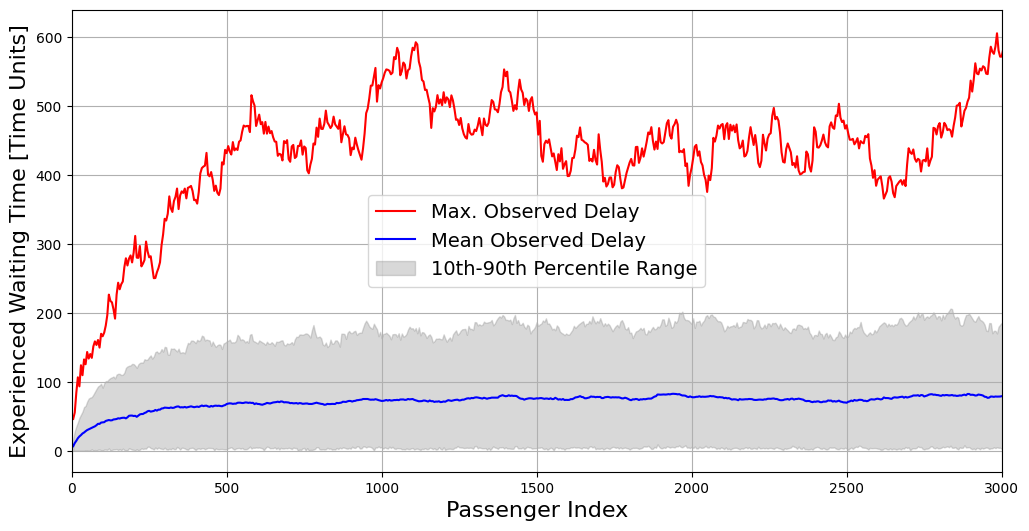

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df_delays.max(axis=0), 'r', label='Max. Observed Delay')
plt.plot(df_delays.mean(axis=0), 'b', label='Mean Observed Delay')

# 90 and 10% percentiles
p90 = np.percentile(df_delays, 90, axis=0)
p10 = np.percentile(df_delays, 10, axis=0)

# Shade the area between the 90th and 10th percentiles
plt.fill_between(df_delays.columns, p90, p10, color='gray', alpha=0.3, label='10th-90th Percentile Range')
plt.xlabel("Passenger Index", fontsize=16)
plt.ylabel("Experienced Waiting Time [Time Units]", fontsize=16)
plt.grid()
plt.xlim(0, 3000)
plt.legend(fontsize=14)
plt.show()

## Step 4: Analysis of Simulation Results in Steady State

In [13]:
# Select the columns between 200 and 1500
subset = df_delays.loc[:, 500:3000]

# Compute the mean, ignoring NaN values
average_delay = subset.mean().mean()
max_delay = df_delays.max().max()


# Select the columns between 200 and 1500
subset = df_queue_lengths.loc[:, 500:3000]

# Compute the mean, ignoring NaN values
average_queue_length = subset.mean().mean()
max_queue_length = df_queue_lengths.max().max()

print(f"Average delay in steady-state: {average_delay:.2f} time units")
print(f"Max delay: {max_delay:.2f} time units")
print(f"Average queue length in steady-state: {average_queue_length:.2f} passengers")
print(f"Max queue length: {max_queue_length:.0f} passengers")

Average delay in steady-state: 74.93 time units
Max delay: 609.47 time units
Average queue length in steady-state: 14.70 passengers
Max queue length: 128 passengers


## Step 5: Comparison of DES Results with Other Modelling Approaches

From the **INFRA-AD** course, you are familiar with two approaches for dimensioning airport infrastructure. One approach is based on modelling methods described in the Airport Development Reference Manual (ADRM), while the other relies on analytical queueing models.

### ADRM Models

The ADRM provides dimensioning approaches for *Processing Facilities*, *Holding Facilities*, and *Flow Facilities*. The gate considered in this example can be classified as a *Processing Facility*.

For processing facilities, the maximum queue length $Q_{max}$ can be determined as follows:

$$
Q_{max} = \frac{K \cdot MQT}{PT/60}
$$

where $K$ is the number of servers (in our case, 1 server), $PT$ is the average processing time in seconds (in our case `mean_service_time = 4.8$ seconds), and $MQT$ represents the temporal level of service. The $MQT$ corresponds to the maximum waiting time that is considered acceptable for a passenger.

Since the ADRM does not define default values for $MQT$, we assume a value of 8.5 minutes (which is approximately equal to the maximum observed delay in the DES simulation). Using the values for $K$, $PT$, and $MQT$, this results in a maximum queue length of $Q_{max} = 106.25$ passengers.

### Analytical Queueing Models

The literature provides a range of analytical queueing models that can be used to determine the expected queue length $E[L_q]$ and the expected waiting time $E[W_q]$ of queueing systems. Since the DES example assumes exponentially distributed arrival and service processes, the formulas of an M/M/1 queueing model can be applied (as introduced in INFRA-AD).

The expected number of passengers in the queue $E[L_q]$ for an **M/M/1 queueing model** is given by:

$$
E[L_q] = \frac{\rho \lambda}{\mu - \lambda}
$$

while the expected waiting time in the queue $E[W_q]$ is:

$$
E[W_q] = \frac{\rho}{\mu - \lambda}
$$

Given that the utilisation ratio is defined as $\rho = \frac{\lambda}{\mu}$, both $E[L_q]$ and $E[W_q]$ can be computed, where $\lambda$ corresponds to the arrival rate (`mean_arrival_rate`) and $\mu$ to the service rate (`mean_service_rate`). This results in $E[L_q] = 12.01$ passengers and $E[W_q] = 62.12$ seconds.

In [14]:
Q_max = 1 * 8.5 /(mean_service_time/60)
print(f"Q_max: {Q_max:.0f} passengers")

rho = mean_arrival_rate / (mean_service_rate)

ELq = rho * mean_arrival_rate / (mean_service_rate - mean_arrival_rate)
print(f"Expected number of passengers in queue (ELq): {ELq:.2f} passengers")

EWq = rho / (mean_service_rate - mean_arrival_rate)
print(f"Expected waiting time in queue (EWq): {EWq:.2f} time units")

Q_max: 106 passengers
Expected number of passengers in queue (ELq): 15.23 passengers
Expected waiting time in queue (EWq): 77.64 time units


### Comparison of ADRM and Analytical Queueing Models with DES Simulation Results

The results obtained from the ADRM and analytical queueing models show strong agreement with the DES simulation results in the **steady state**. The following observations are particularly noteworthy:

- The results from the analytical queueing model (i.e., $E[L_q]$ and $E[W_q]$) closely match the simulated mean values of $L_q$ and $W_q$ in the steady state.
- The results from the ADRM models (i.e., $Q_{max}$) correspond well to the observed maximum values of $L_q$ and $W_q$ in the steady state.